In [1]:
# ============================================================
# CELLA 1 - Import e setup
# ============================================================
import sys
import os
import yaml
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from src.datasets.gqa_graph_dataset import GQAGraphDataset
from src.models.gnn import GCNEmbeddingNet, GINEEmbeddingNet
from src.evaluation.retrieval import (
    gcn_compute_graph_embeddings,
    compute_graph_embeddings,
    evaluate_retrieval,
)
from src.utils.perturb import perturb_dataframe


p:\Anaconda\envs\torch_old\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# ============================================================
# CELLA 2 - Caricamento GCN
# ============================================================
config_path = os.path.join(BASE_DIR, "experiments", "configs", "gcn_config.yaml")
with open(config_path) as f:
    cfg_gcn = yaml.safe_load(f)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path  = os.path.join(BASE_DIR, cfg_gcn["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab_gcn = checkpoint["node_vocab"]
rel_vocab_gcn  = checkpoint["rel_vocab"]

gcn_model = GCNEmbeddingNet(
    num_node_types=len(node_vocab_gcn) + 1,
    emb_dim=cfg_gcn["model"]["emb_dim"],
    hidden_dim=cfg_gcn["model"]["hidden_dim"],
    num_layers=cfg_gcn["model"]["num_layers"],
    dropout=cfg_gcn["model"]["dropout"],
    use_bbox=cfg_gcn["model"]["use_bbox"],
    node_emb_dim=cfg_gcn["model"]["node_emb_dim"],
).to(device)

gcn_model.load_state_dict(checkpoint["model_state_dict"])
gcn_model.eval()
print(f"GCN caricato da: {ckpt_path}")



GCN caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gcn20.pth


In [3]:

# ============================================================
# CELLA 3 - Caricamento GINE
# ============================================================
config_path = os.path.join(BASE_DIR, "experiments", "configs", "gine_config.yaml")
with open(config_path) as f:
    cfg_gine = yaml.safe_load(f)

ckpt_path  = os.path.join(BASE_DIR, cfg_gine["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab_gine = checkpoint["node_vocab"]
rel_vocab_gine  = checkpoint["rel_vocab"]

gine_model = GINEEmbeddingNet(
    num_node_types=len(node_vocab_gine) + 1,
    edge_vocab_size=len(rel_vocab_gine),
    emb_dim=cfg_gine["model"]["emb_dim"],
    hidden_dim=cfg_gine["model"]["hidden_dim"],
    num_layers=cfg_gine["model"]["num_layers"],
    dropout=cfg_gine["model"]["dropout"],
    use_bbox=cfg_gine["model"]["use_bbox"],
    node_emb_dim=cfg_gine["model"]["node_emb_dim"],
).to(device)

gine_model.load_state_dict(checkpoint["model_state_dict"])
gine_model.eval()
print(f"GINE caricato da: {ckpt_path}")



GINE caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gnn20.pth


In [4]:

# ============================================================
# CELLA 4 - Data
# ============================================================
df_train = pd.read_csv(os.path.join(BASE_DIR, cfg_gcn["data"]["train_csv"]))
df_val   = pd.read_csv(os.path.join(BASE_DIR, cfg_gcn["data"]["val_csv"]))

all_labels = df_train["labels"].unique()
label2idx  = {l: i for i, l in enumerate(all_labels)}
idx2label  = {i: l for l, i in label2idx.items()}

df_train["labels"] = df_train["labels"].map(label2idx)
df_val["labels"]   = df_val["labels"].map(label2idx)



In [5]:

# ============================================================
# CELLA 5 - Sweep perturbazione: 0, 0.3, 0.5, 0.7
# ============================================================
drop_probs = [0.0, 0.3, 0.5, 0.7]

results_gcn  = {"precision_macro": [], "recall_macro": [], "acc@1": [], "map": []}
results_gine = {"precision_macro": [], "recall_macro": [], "acc@1": [], "map": []}

for drop_prob in drop_probs:
    print(f"\n--- drop_prob = {drop_prob} ---")

    # dataset perturbato (drop_prob=0 → dataset originale)
    perturbed_df = perturb_dataframe(df_val, drop_prob=drop_prob) if drop_prob > 0 else df_val.copy()

    # --- GCN ---
    val_dataset_gcn = GQAGraphDataset(
        df=perturbed_df, label_col="labels",
        node_vocab=node_vocab_gcn, rel_vocab=rel_vocab_gcn,
        label2idx=label2idx, idx2label=idx2label,
        use_bbox=cfg_gcn["model"]["use_bbox"],
    )

    emb_gcn, lbl_gcn = gcn_compute_graph_embeddings(
        model=gcn_model, dataset=val_dataset_gcn, device=device,
        batch_size=cfg_gcn["dataloader"]["batch_size"],
        num_workers=cfg_gcn["dataloader"]["num_workers"],
        normalize=True,
    )
    res_gcn, _, _ = evaluate_retrieval(emb_gcn, lbl_gcn, ks=(1, 5, 10))

    for k in results_gcn:
        results_gcn[k].append(res_gcn[k])

    print(f"  GCN  | precision_macro={res_gcn['precision_macro']:.4f} | recall_macro={res_gcn['recall_macro']:.4f} | acc@1={res_gcn['acc@1']:.4f} | map={res_gcn['map']:.4f}")

    # --- GINE ---
    val_dataset_gine = GQAGraphDataset(
        df=perturbed_df, label_col="labels",
        node_vocab=node_vocab_gine, rel_vocab=rel_vocab_gine,
        label2idx=label2idx, idx2label=idx2label,
        use_bbox=cfg_gine["model"]["use_bbox"],
    )

    emb_gine, lbl_gine = compute_graph_embeddings(
        model=gine_model, dataset=val_dataset_gine, device=device,
        batch_size=cfg_gine["dataloader"]["batch_size"],
        num_workers=cfg_gine["dataloader"]["num_workers"],
        normalize=True,
    )
    res_gine, _, _ = evaluate_retrieval(emb_gine, lbl_gine, ks=(1, 5, 10))

    for k in results_gine:
        results_gine[k].append(res_gine[k])

    print(f"  GINE | precision_macro={res_gine['precision_macro']:.4f} | recall_macro={res_gine['recall_macro']:.4f} | acc@1={res_gine['acc@1']:.4f} | map={res_gine['map']:.4f}")



--- drop_prob = 0.0 ---
  GCN  | precision_macro=0.5598 | recall_macro=0.5538 | acc@1=0.5966 | map=0.6594
  GINE | precision_macro=0.4878 | recall_macro=0.4892 | acc@1=0.4991 | map=0.5778

--- drop_prob = 0.3 ---
  GCN  | precision_macro=0.5232 | recall_macro=0.5188 | acc@1=0.5592 | map=0.6236
  GINE | precision_macro=0.4277 | recall_macro=0.4315 | acc@1=0.4498 | map=0.5315

--- drop_prob = 0.5 ---
  GCN  | precision_macro=0.4519 | recall_macro=0.4567 | acc@1=0.5103 | map=0.5821
  GINE | precision_macro=0.3795 | recall_macro=0.3813 | acc@1=0.4152 | map=0.5047

--- drop_prob = 0.7 ---
  GCN  | precision_macro=0.3817 | recall_macro=0.3822 | acc@1=0.4514 | map=0.5299
  GINE | precision_macro=0.3197 | recall_macro=0.3147 | acc@1=0.3582 | map=0.4554


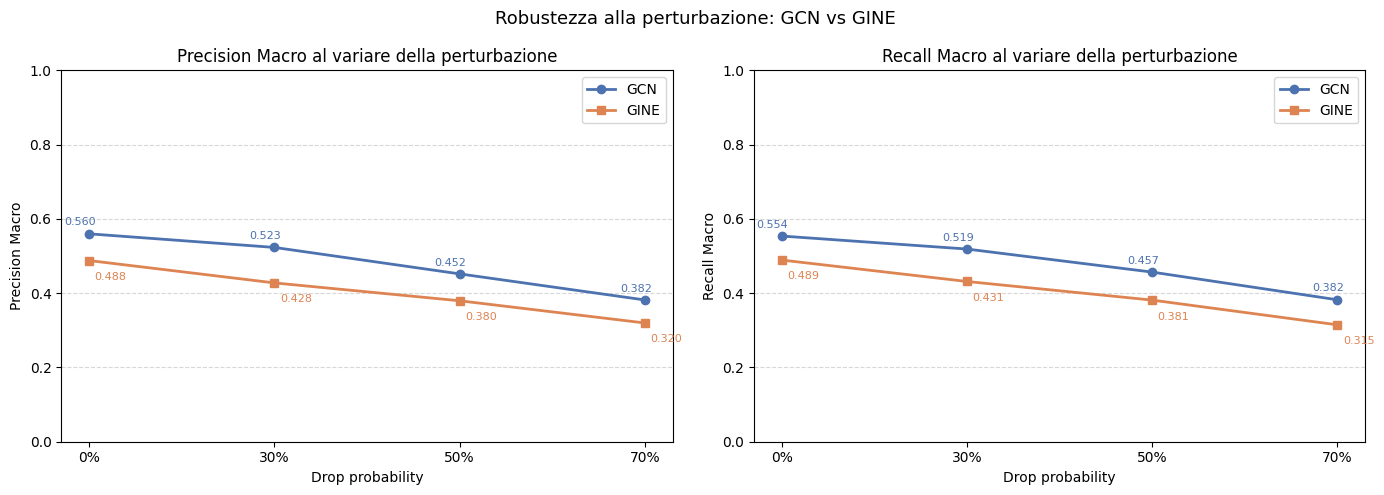

In [6]:


# ============================================================
# CELLA 6 - Plot precision_macro e recall_macro
# ============================================================
x_labels = [f"{int(p*100)}%" for p in drop_probs]
x        = np.arange(len(drop_probs))
width    = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_to_plot = ["precision_macro", "recall_macro"]
titles          = ["Precision Macro", "Recall Macro"]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    vals_gcn  = results_gcn[metric]
    vals_gine = results_gine[metric]

    ax.plot(x, vals_gcn,  marker="o", linewidth=2, label="GCN",  color="#4C72B0")
    ax.plot(x, vals_gine, marker="s", linewidth=2, label="GINE", color="#DD8452")

    # annotazioni valori
    for i, (vg, vi) in enumerate(zip(vals_gcn, vals_gine)):
        ax.annotate(f"{vg:.3f}", (x[i], vg), textcoords="offset points",
                    xytext=(-18, 6), fontsize=8, color="#4C72B0")
        ax.annotate(f"{vi:.3f}", (x[i], vi), textcoords="offset points",
                    xytext=(4, -14), fontsize=8, color="#DD8452")

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("Drop probability")
    ax.set_ylabel(title)
    ax.set_title(f"{title} al variare della perturbazione")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_ylim(0, 1)

plt.suptitle("Robustezza alla perturbazione: GCN vs GINE", fontsize=13)
plt.tight_layout()
plt.show()



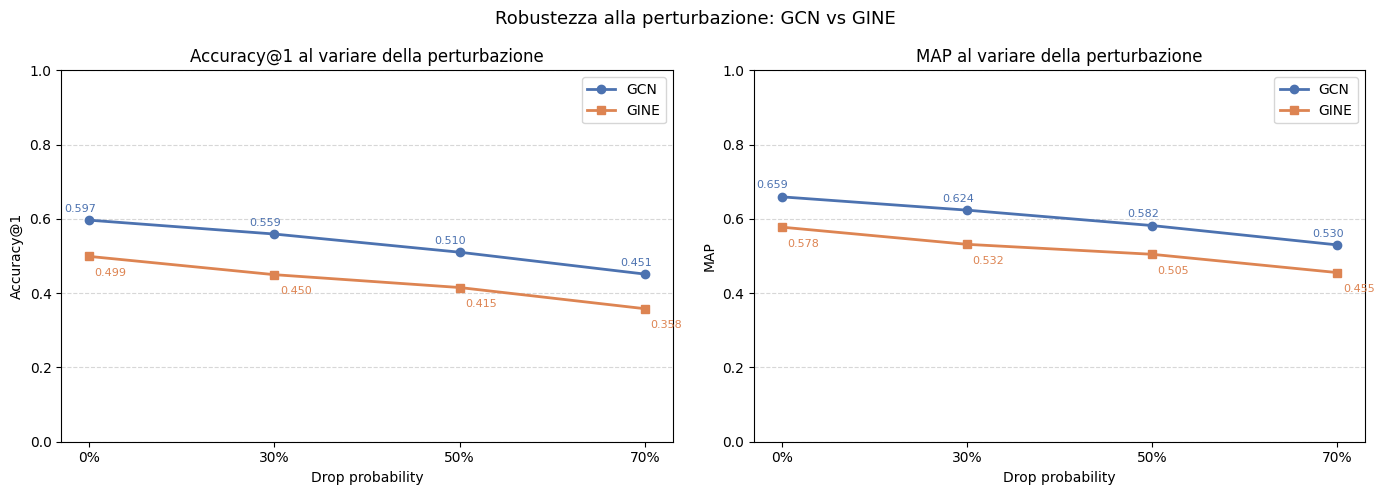

In [7]:

# ============================================================
# CELLA 7 - Plot acc@1 e MAP
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_to_plot = ["acc@1", "map"]
titles          = ["Accuracy@1", "MAP"]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    vals_gcn  = results_gcn[metric]
    vals_gine = results_gine[metric]

    ax.plot(x, vals_gcn,  marker="o", linewidth=2, label="GCN",  color="#4C72B0")
    ax.plot(x, vals_gine, marker="s", linewidth=2, label="GINE", color="#DD8452")

    for i, (vg, vi) in enumerate(zip(vals_gcn, vals_gine)):
        ax.annotate(f"{vg:.3f}", (x[i], vg), textcoords="offset points",
                    xytext=(-18, 6), fontsize=8, color="#4C72B0")
        ax.annotate(f"{vi:.3f}", (x[i], vi), textcoords="offset points",
                    xytext=(4, -14), fontsize=8, color="#DD8452")

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("Drop probability")
    ax.set_ylabel(title)
    ax.set_title(f"{title} al variare della perturbazione")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_ylim(0, 1)

plt.suptitle("Robustezza alla perturbazione: GCN vs GINE", fontsize=13)
plt.tight_layout()
plt.show()


In [8]:


# ============================================================
# CELLA 8 - Tabella riassuntiva
# ============================================================
rows = []
for i, p in enumerate(drop_probs):
    rows.append({
        "drop_prob": f"{int(p*100)}%",
        "GCN precision_macro":  round(results_gcn["precision_macro"][i],  4),
        "GCN recall_macro":     round(results_gcn["recall_macro"][i],     4),
        "GCN acc@1":            round(results_gcn["acc@1"][i],            4),
        "GCN map":              round(results_gcn["map"][i],              4),
        "GINE precision_macro": round(results_gine["precision_macro"][i], 4),
        "GINE recall_macro":    round(results_gine["recall_macro"][i],    4),
        "GINE acc@1":           round(results_gine["acc@1"][i],           4),
        "GINE map":             round(results_gine["map"][i],             4),
    })

summary_df = pd.DataFrame(rows).set_index("drop_prob")
print(summary_df.to_string())


           GCN precision_macro  GCN recall_macro  GCN acc@1  GCN map  GINE precision_macro  GINE recall_macro  GINE acc@1  GINE map
drop_prob                                                                                                                          
0%                      0.5598            0.5538     0.5966   0.6594                0.4878             0.4892      0.4991    0.5778
30%                     0.5232            0.5188     0.5592   0.6236                0.4277             0.4315      0.4498    0.5315
50%                     0.4519            0.4567     0.5103   0.5821                0.3795             0.3813      0.4152    0.5047
70%                     0.3817            0.3822     0.4514   0.5299                0.3197             0.3147      0.3582    0.4554
